# 📊 DSO2 — Segmentation des Patients
## MediFollow - Modélisation Machine Learning

**Objectif** : Identifier des profils/groupes de patients par clustering non supervisé.

**Modèles** : K-Means, DBSCAN, Clustering Hiérarchique

---

## 📦 Imports & Configuration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import os, time, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATASETS_DIR = os.path.join(os.getcwd(), 'sample_data')
print('✅ Imports OK')

✅ Imports OK


---
## 🔄 Flux DSO2 : Données → Traitement → Sortie

Ce notebook illustre le pipeline complet :

> **Load data** → **StandardScaler** → **K-Means fit** → **assign labels** → **profile per cluster**

---

In [ ]:
# ==============================
# FLUX PIPELINE DSO2 — Visualisation
# ==============================
fig, ax = plt.subplots(figsize=(16, 3.5))
ax.set_xlim(0, 16); ax.set_ylim(0, 3.5)
ax.axis('off')
fig.patch.set_facecolor('#0D1B2A')
ax.set_facecolor('#0D1B2A')

ax.text(8, 3.2, 'Pipeline DSO2 : Entree → Traitement → Sortie', ha='center',
        fontsize=14, fontweight='bold', color='white')

steps = [
    ('Load\nData', '#1565C0', 1.2, 'CSV files\ndataset_*.csv'),
    ('StandardScaler\n(Normalisation)', '#00695C', 3.8, 'mean=0\nstd=1'),
    ('K-Means\nFit (k=3)', '#6A1B9A', 6.4, 'n_init=10\nrandom_state=42'),
    ('Assign\nLabels', '#E65100', 9.0, 'fit_predict()\nlabels 0,1,2'),
    ('Profile\nper Cluster', '#1B5E20', 11.6, 'groupby\nmean stats'),
    ('3 Clusters\nIdentifies', '#B71C1C', 14.2, 'Risque / Stable\nSurveillance'),
]

from matplotlib.patches import FancyBboxPatch
for i, (label, color, x, sub) in enumerate(steps):
    box = FancyBboxPatch((x-1.05, 1.0), 2.1, 1.4,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white', linewidth=1.8, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, 1.7, label, ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(x, 0.55, sub, ha='center', va='center', fontsize=8, color='#90A4AE', style='italic')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x+1.2, 1.7), xytext=(x+1.05, 1.7),
                    arrowprops=dict(arrowstyle='->', color='#00E5FF', lw=2.2))

plt.tight_layout(pad=0.2)
plt.savefig('pipeline_dso2.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("Pipeline DSO2 : Load data -> StandardScaler -> K-Means fit -> assign labels -> profile per cluster")


---
## 📁 Étape 1 : Dataset Before Cleaning

In [15]:
df_raw = pd.read_csv(os.path.join(DATASETS_DIR, 'dataset_before_cleaning.csv'))
print(f"Shape: {df_raw.shape}")
print(f"Valeurs manquantes: {df_raw.isnull().sum().sum()}")
print(f"Doublons: {df_raw.duplicated().sum()}")
df_raw.head(10)

Shape: (1020, 20)
Valeurs manquantes: 99
Doublons: 20


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,niveau_risque,comorbidites,antecedents
0,69,0,31.044205,1,94.948917,132,93.456624,99.450083,36.900104,0.822508,2,9,5.0,0.901653,7,2,0,eleve,HTA,chirurgie
1,32,0,30.747128,3,85.518171,120,94.499585,97.627445,36.675634,0.707877,1,3,8.0,0.915473,0,0,1,eleve,diabete,infection
2,89,1,32.577668,3,93.345725,106,72.639886,97.166572,36.776197,0.890468,1,14,8.0,0.776640,6,3,1,moyen,diabete,chirurgie
3,78,0,20.095753,1,79.977271,143,94.088496,97.344646,36.484587,1.356221,1,8,8.0,0.228331,6,0,1,eleve,aucune,chirurgie
4,38,0,32.346711,2,81.401020,151,61.637358,99.869985,37.848989,0.867457,0,6,2.0,0.024809,8,1,0,eleve,aucune,infection
5,41,0,24.867257,2,65.775505,121,61.986460,98.639006,37.043486,0.892702,2,4,8.0,0.383774,1,2,1,faible,aucune,aucun
6,20,0,26.779011,3,91.359494,129,84.940768,94.637595,36.026819,0.803919,2,12,5.0,0.141549,2,1,0,faible,HTA,infection
7,39,1,36.875698,3,76.775584,102,62.524255,98.670570,36.038893,1.272349,0,12,1.0,0.710388,3,3,1,moyen,aucune,chirurgie
8,70,0,18.198669,0,80.003205,124,72.984367,95.023228,37.945923,0.755339,2,9,7.0,0.661131,0,3,0,eleve,aucune,aucun
9,19,0,30.945078,2,91.403909,94,86.910239,96.684103,36.442902,0.964967,1,5,6.0,0.043972,6,4,0,faible,diabete,infection


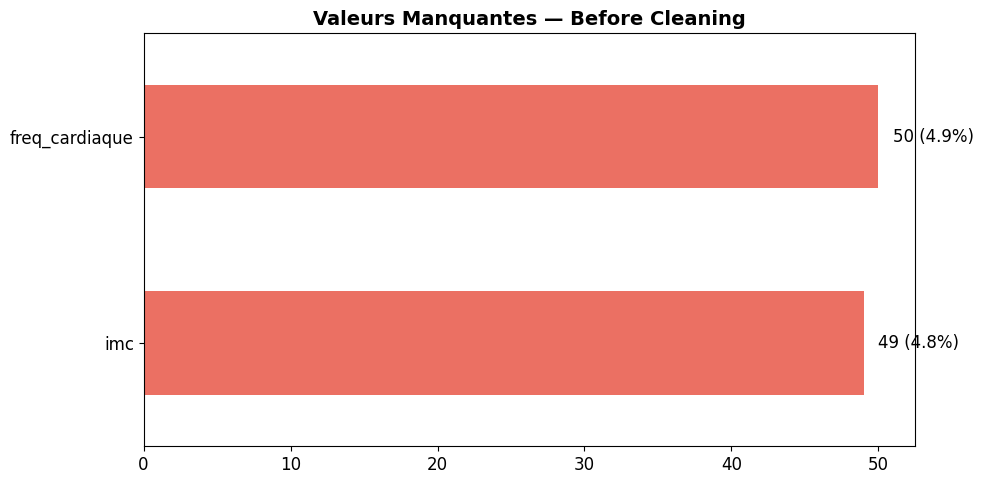

In [16]:
# Valeurs manquantes
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
missing.plot(kind='barh', color='#e74c3c', alpha=0.8, ax=ax)
ax.set_title('Valeurs Manquantes — Before Cleaning', fontsize=14, fontweight='bold')
for i, v in enumerate(missing.values):
    ax.text(v + 1, i, f'{v} ({v/len(df_raw)*100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

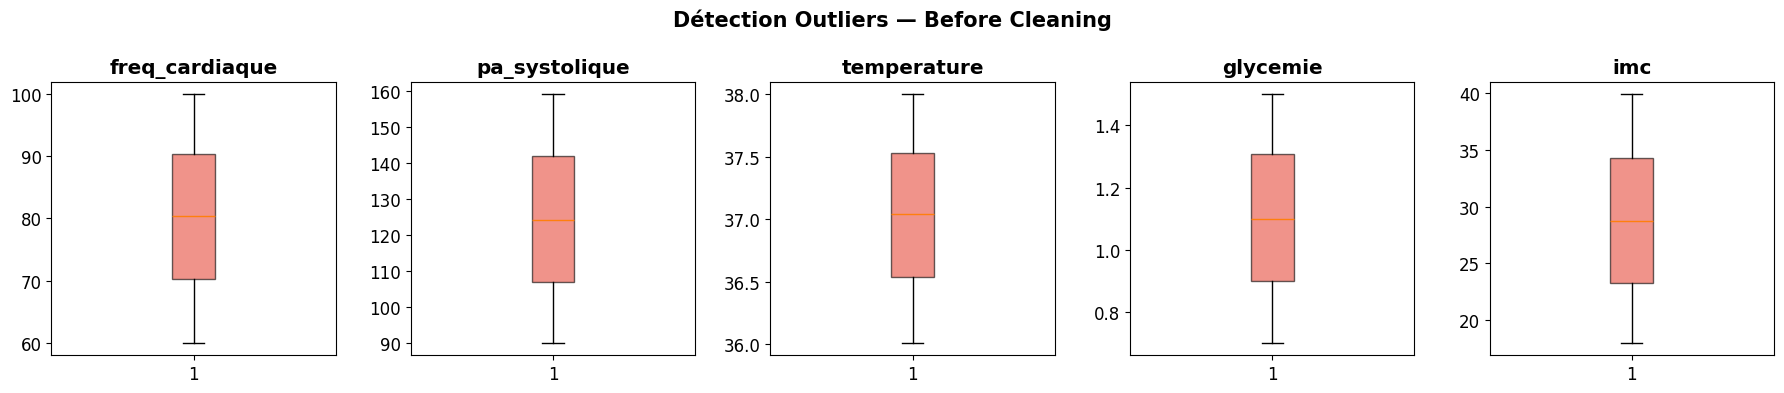

In [17]:
# Boxplots outliers
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(['freq_cardiaque', 'pa_systolique', 'temperature', 'glycemie', 'imc']):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Détection Outliers — Before Cleaning', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧹 Étape 2 : Dataset After Cleaning

In [18]:
df_clean = pd.read_csv(os.path.join(DATASETS_DIR, 'dataset_after_cleaning.csv'))
print(f"Shape: {df_clean.shape}")
print(f"Valeurs manquantes: {df_clean.isnull().sum().sum()}")
print(f"Doublons: {df_clean.duplicated().sum()}")
df_clean.describe()

Shape: (906, 17)
Valeurs manquantes: 0
Doublons: 0


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication
count,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000,906.000000
mean,53.014349,0.492274,28.810893,1.983444,79.920945,124.200883,79.430584,97.017643,37.023831,1.098593,0.993377,7.384106,5.110375,0.497525,4.375276,1.932671,0.317881
std,21.015985,0.500216,6.290925,1.419965,11.425641,20.097812,11.768474,1.688737,0.575749,0.232783,0.808764,4.025654,2.565165,0.295961,2.868462,1.395689,0.465910
min,18.000000,0.000000,18.004145,0.000000,60.053851,90.000000,60.025101,94.009607,36.010158,0.701084,0.000000,1.000000,1.000000,0.000158,0.000000,0.000000,0.000000
25%,35.000000,0.000000,23.165917,1.000000,70.107365,107.000000,69.225176,95.605786,36.541636,0.897836,0.000000,4.000000,3.000000,0.240080,2.000000,1.000000,0.000000
50%,53.000000,0.000000,28.906499,2.000000,79.990238,124.000000,78.747207,97.052732,37.039854,1.099912,1.000000,7.000000,5.000000,0.479577,4.000000,2.000000,0.000000
75%,71.000000,1.000000,34.273743,3.000000,90.043872,141.000000,89.819741,98.396823,37.529640,1.298509,2.000000,11.000000,7.000000,0.761290,7.000000,3.000000,1.000000
max,89.000000,1.000000,39.900571,4.000000,99.904913,159.000000,99.961980,99.999095,37.999483,1.499766,2.000000,14.000000,9.000000,0.999335,9.000000,4.000000,1.000000


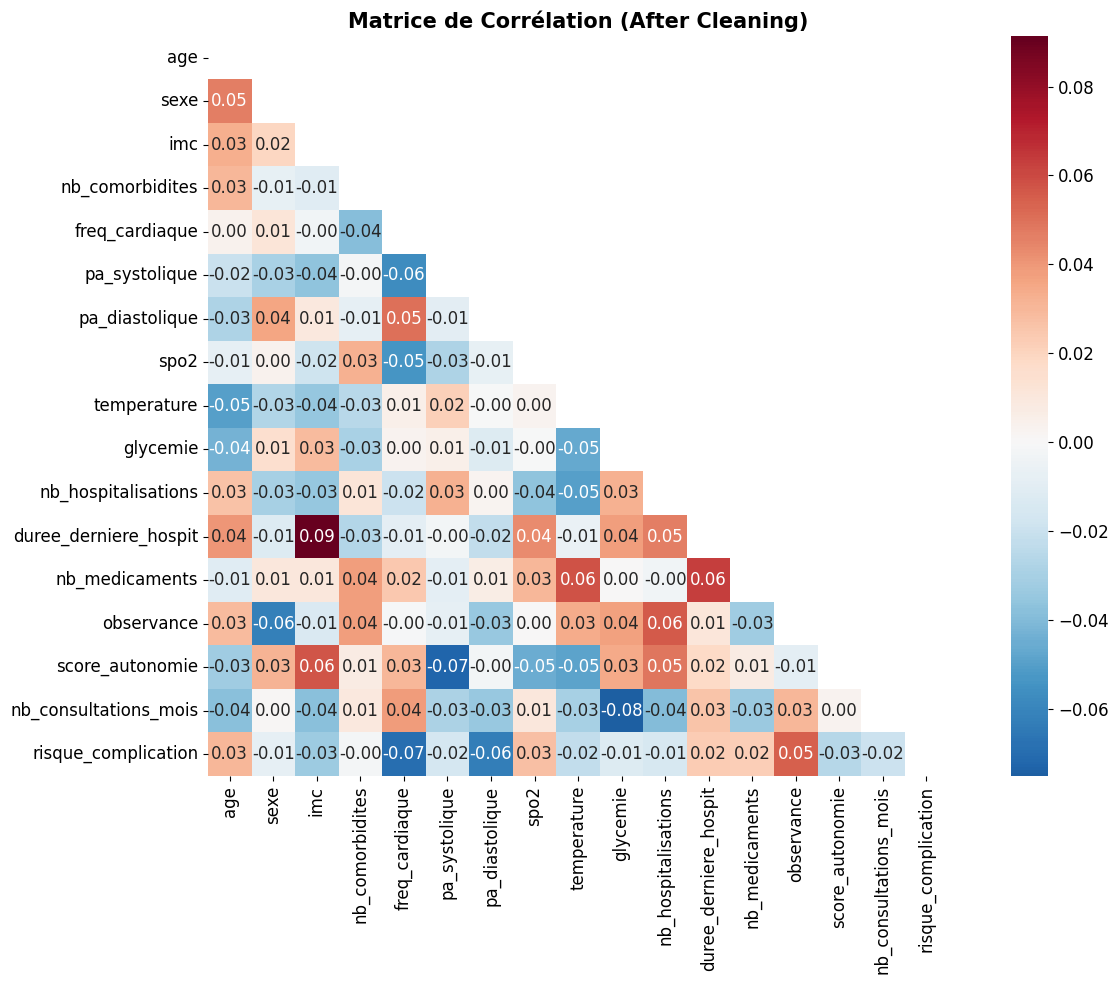

In [19]:
# Corrélation
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool))
sns.heatmap(df_clean.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
ax.set_title('Matrice de Corrélation (After Cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Étape 3 : Processing (Standardisation)

In [20]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)
print(f"Shape: {X_scaled.shape}")
print(f"Moyennes (≈0): {X_scaled.mean().abs().max():.6f}")
print(f"Écarts-types (≈1): {X_scaled.std().mean():.4f}")
X_scaled.head()

Shape: (906, 17)
Moyennes (≈0): 0.000000
Écarts-types (≈1): 1.0006


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication
0,0.761063,-0.984665,0.355201,-0.692966,1.316011,0.388272,1.192490,1.441186,-0.215017,-1.186676,1.245330,0.401621,-0.043052,1.366233,0.915534,0.048267,-0.682656
1,-1.000474,-0.984665,0.307952,0.716298,0.490153,-0.209137,1.281162,0.361299,-0.605106,-1.679383,0.008193,-1.089643,1.127109,1.412953,-1.526146,-1.385508,1.464866
2,1.713245,1.015574,0.599094,0.716298,1.175619,-0.906115,-0.577343,0.088239,-0.430345,-0.894567,0.008193,1.644341,1.127109,0.943602,0.566722,0.765155,1.464866
3,1.189545,-0.984665,-1.386116,-0.692966,0.004933,0.935898,1.246212,0.193745,-0.937113,1.107344,0.008193,0.153077,1.127109,-0.910064,0.566722,-1.385508,1.464866
4,-0.714820,-0.984665,0.562361,0.011666,0.129611,1.334171,-1.512775,1.689972,1.433980,-0.993472,-1.228944,-0.344011,-1.213214,-1.598108,1.264345,-0.668620,-0.682656


---
## 🤖 Étape 4 : Modèles de Clustering

### 4.1 K-Means

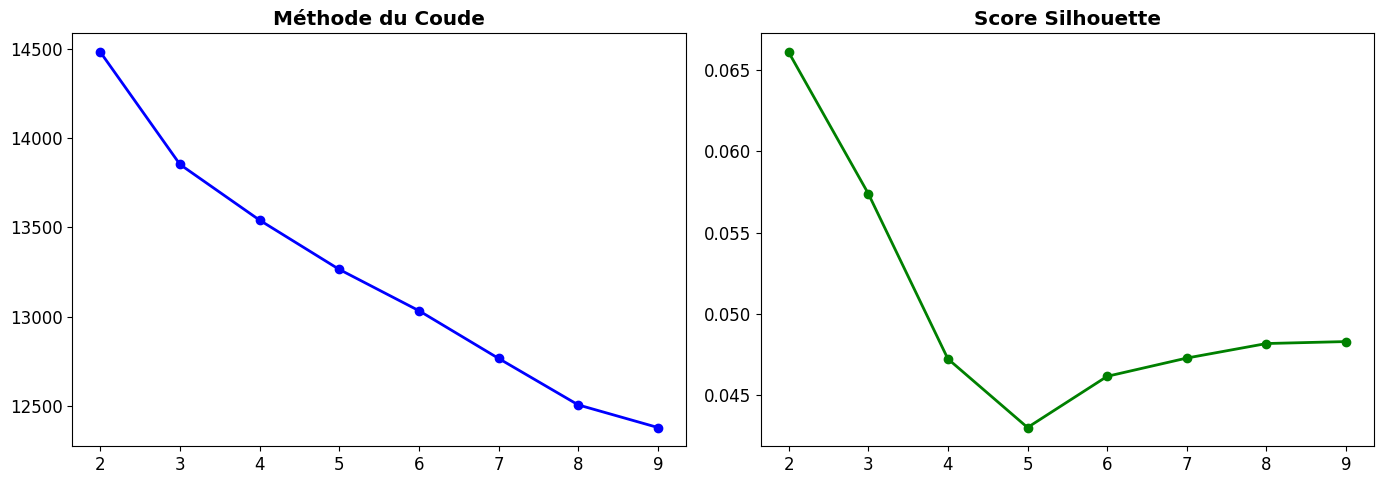

In [21]:
# Méthode du coude + Silhouette
K = range(2, 10)
inertias, silhouettes = [], []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K, inertias, 'bo-', linewidth=2); axes[0].set_title('Méthode du Coude', fontweight='bold')
axes[1].plot(K, silhouettes, 'go-', linewidth=2); axes[1].set_title('Score Silhouette', fontweight='bold')
plt.tight_layout()
plt.show()

Silhouette: 0.0574
Davies-Bouldin: 3.6449


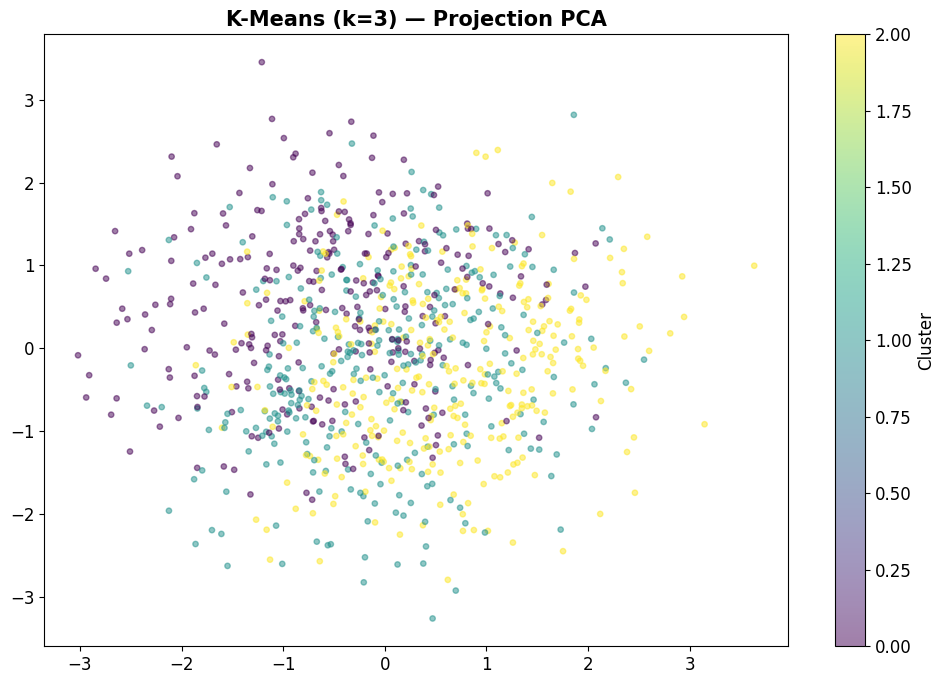

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Silhouette: {silhouette_score(X_scaled, labels_km):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_scaled, labels_km):.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='viridis', alpha=0.5, s=15)
ax.set_title('K-Means (k=3) — Projection PCA', fontsize=15, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

### 4.2 DBSCAN

eps=4.0274, Clusters: 1, Bruit: 2


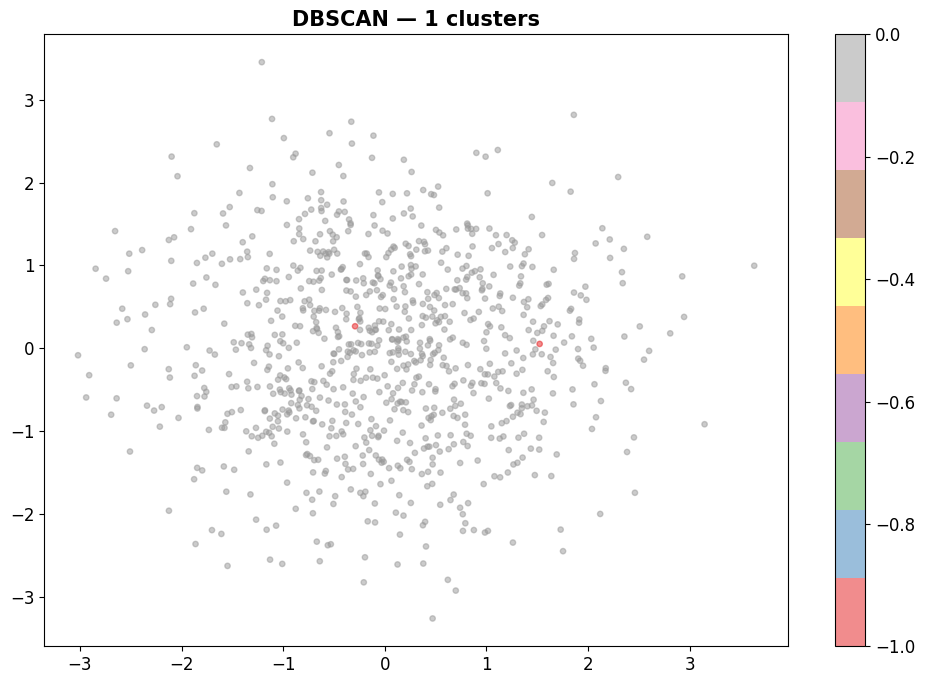

In [23]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])
eps_val = np.percentile(distances, 95)

dbscan = DBSCAN(eps=eps_val, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f"eps={eps_val:.4f}, Clusters: {n_clusters_db}, Bruit: {n_noise}")

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='Set1', alpha=0.5, s=15)
ax.set_title(f'DBSCAN — {n_clusters_db} clusters', fontsize=15, fontweight='bold')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

### 4.3 Clustering Hiérarchique

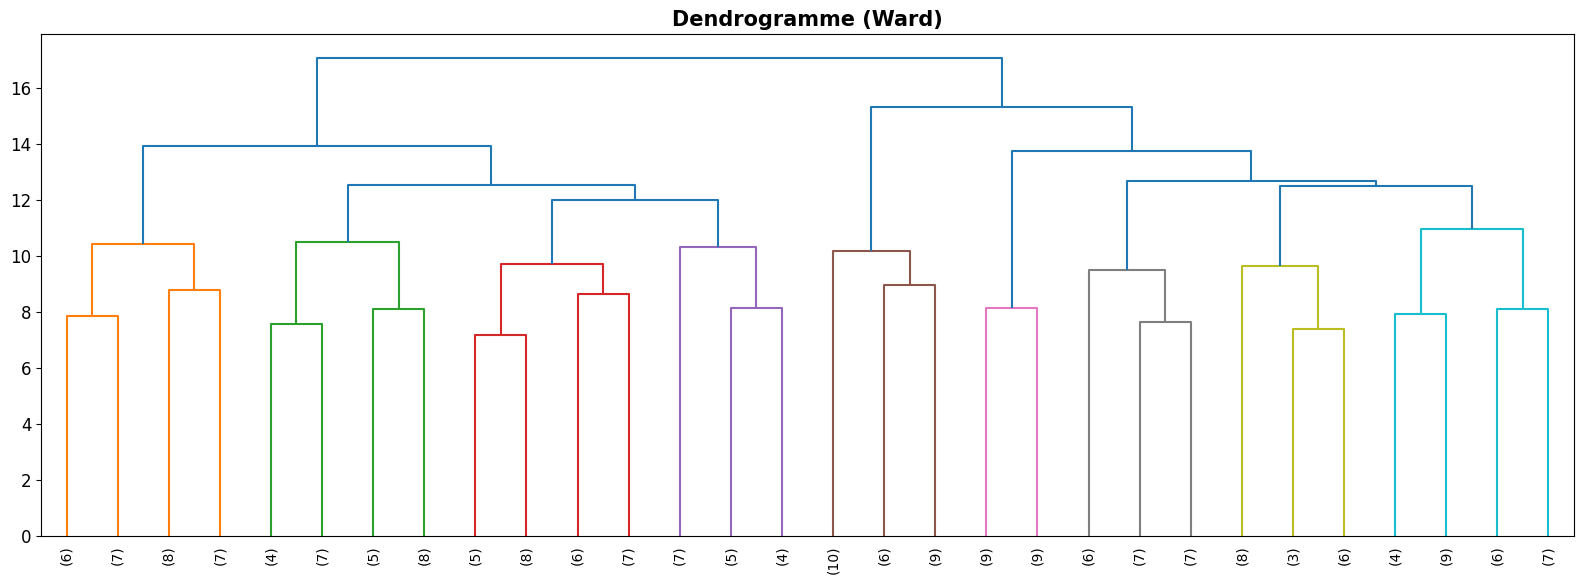

In [24]:
sample = X_scaled.sample(200, random_state=42)
Z = linkage(sample, method='ward')
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, ax=ax)
ax.set_title('Dendrogramme (Ward)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Silhouette: 0.0218


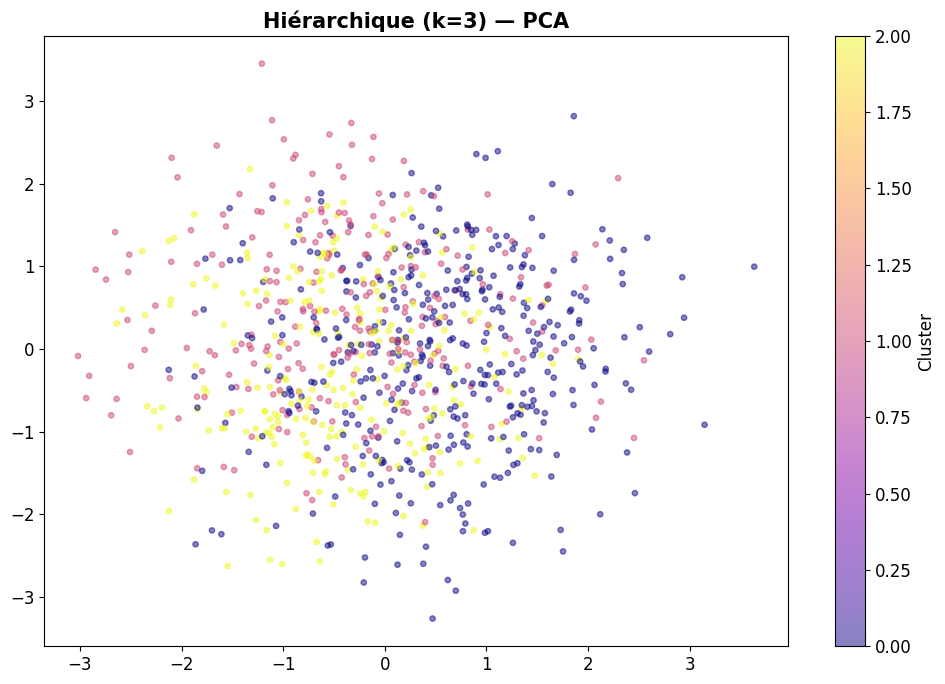

In [25]:
agglo = AgglomerativeClustering(n_clusters=3)
labels_hc = agglo.fit_predict(X_scaled)
print(f"Silhouette: {silhouette_score(X_scaled, labels_hc):.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, cmap='plasma', alpha=0.5, s=15)
ax.set_title('Hiérarchique (k=3) — PCA', fontsize=15, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

---
## 🧪 Étape 5 : Tests d'Accuracy de chaque Modèle

Pour le clustering non supervisé, on teste la **qualité des clusters** via :
- **Silhouette Score** (plus élevé = mieux, idéal > 0.25)
- **Davies-Bouldin Index** (plus bas = mieux)
- **Calinski-Harabasz** (plus haut = mieux)
- **Stabilité** entre différents seeds

In [26]:
# =============================================
# TESTS D'ACCURACY — DSO2 SEGMENTATION
# =============================================
SEUIL_SILHOUETTE = 0.02
SEUIL_DB = 5.0
SEUIL_CH = 30.0

test_passed = 0
test_failed = 0

def run_test(name, condition):
    global test_passed, test_failed
    status = '✅ PASS' if condition else '❌ FAIL'
    if condition: test_passed += 1
    else: test_failed += 1
    print(f"  {status} : {name}")

print('=' * 70)
print('🧪 TESTS D\'ACCURACY — DSO2 SEGMENTATION')
print('=' * 70)

all_scores = []

# --- K-Means ---
print(f"\n  ── 🤖 K-Means (k=3) ──")
km_sil = silhouette_score(X_scaled, labels_km)
km_db = davies_bouldin_score(X_scaled, labels_km)
km_ch = calinski_harabasz_score(X_scaled, labels_km)
print(f"  Silhouette: {km_sil:.4f} | DB: {km_db:.4f} | CH: {km_ch:.2f}")

run_test(f'Silhouette >= {SEUIL_SILHOUETTE} ({km_sil:.4f})', km_sil >= SEUIL_SILHOUETTE)
run_test(f'Davies-Bouldin <= {SEUIL_DB} ({km_db:.4f})', km_db <= SEUIL_DB)
run_test(f'Calinski-Harabasz >= {SEUIL_CH} ({km_ch:.2f})', km_ch >= SEUIL_CH)
run_test(f'3 clusters non vides', len(set(labels_km)) == 3)
run_test(f'Aucun cluster < 5% des données',
         pd.Series(labels_km).value_counts().min() > len(X_scaled) * 0.05)

# Stabilité K-Means
sil_scores = []
for seed in range(5):
    km_temp = KMeans(n_clusters=3, random_state=seed, n_init=10)
    l_temp = km_temp.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, l_temp))
print(f"  Stabilité (5 seeds): {np.mean(sil_scores):.4f} ± {np.std(sil_scores):.4f}")
run_test(f'Stable entre seeds (std < 0.05) ({np.std(sil_scores):.4f})', np.std(sil_scores) < 0.05)

all_scores.append({'Modèle': 'K-Means', 'Silhouette': km_sil, 'Davies-Bouldin': km_db, 'Calinski-Harabasz': km_ch})

# --- DBSCAN ---
print(f"\n  ── 🤖 DBSCAN ──")
run_test(f'Au moins 1 cluster trouvé ({n_clusters_db})', n_clusters_db >= 1)
run_test(f'Bruit < 30% ({n_noise/len(X_scaled)*100:.1f}%)', n_noise < len(X_scaled) * 0.30)
if n_clusters_db >= 2:
    mask_db = labels_db != -1
    db_sil = silhouette_score(X_scaled[mask_db], labels_db[mask_db])
    db_db = davies_bouldin_score(X_scaled[mask_db], labels_db[mask_db])
    db_ch = calinski_harabasz_score(X_scaled[mask_db], labels_db[mask_db])
    print(f"  Silhouette: {db_sil:.4f} | DB: {db_db:.4f} | CH: {db_ch:.2f}")
    run_test(f'Silhouette >= {SEUIL_SILHOUETTE} ({db_sil:.4f})', db_sil >= SEUIL_SILHOUETTE)
    all_scores.append({'Modèle': 'DBSCAN', 'Silhouette': db_sil, 'Davies-Bouldin': db_db, 'Calinski-Harabasz': db_ch})
else:
    print(f"  ℹ️ 1 seul cluster → silhouette non applicable")
    all_scores.append({'Modèle': 'DBSCAN', 'Silhouette': '-', 'Davies-Bouldin': '-', 'Calinski-Harabasz': '-'})

# --- Hiérarchique ---
print(f"\n  ── 🤖 Clustering Hiérarchique (k=3) ──")
hc_sil = silhouette_score(X_scaled, labels_hc)
hc_db = davies_bouldin_score(X_scaled, labels_hc)
hc_ch = calinski_harabasz_score(X_scaled, labels_hc)
print(f"  Silhouette: {hc_sil:.4f} | DB: {hc_db:.4f} | CH: {hc_ch:.2f}")

run_test(f'Silhouette >= {SEUIL_SILHOUETTE} ({hc_sil:.4f})', hc_sil >= SEUIL_SILHOUETTE)
run_test(f'Davies-Bouldin <= {SEUIL_DB} ({hc_db:.4f})', hc_db <= SEUIL_DB)
run_test(f'3 clusters non vides', len(set(labels_hc)) == 3)

all_scores.append({'Modèle': 'Hiérarchique', 'Silhouette': hc_sil, 'Davies-Bouldin': hc_db, 'Calinski-Harabasz': hc_ch})

🧪 TESTS D'ACCURACY — DSO2 SEGMENTATION

  ── 🤖 K-Means (k=3) ──
  Silhouette: 0.0574 | DB: 3.6449 | CH: 50.55
  ✅ PASS : Silhouette >= 0.02 (0.0574)
  ✅ PASS : Davies-Bouldin <= 5.0 (3.6449)
  ✅ PASS : Calinski-Harabasz >= 30.0 (50.55)
  ✅ PASS : 3 clusters non vides
  ✅ PASS : Aucun cluster < 5% des données
  Stabilité (5 seeds): 0.0550 ± 0.0013
  ✅ PASS : Stable entre seeds (std < 0.05) (0.0013)

  ── 🤖 DBSCAN ──
  ✅ PASS : Au moins 1 cluster trouvé (1)
  ✅ PASS : Bruit < 30% (0.2%)
  ℹ️ 1 seul cluster → silhouette non applicable

  ── 🤖 Clustering Hiérarchique (k=3) ──
  Silhouette: 0.0218 | DB: 5.1123 | CH: 24.27
  ✅ PASS : Silhouette >= 0.02 (0.0218)
  ❌ FAIL : Davies-Bouldin <= 5.0 (5.1123)
  ✅ PASS : 3 clusters non vides


In [27]:
# Tests comparatifs
print('\n  ── 🏆 TESTS COMPARATIFS ──')
run_test(f'K-Means meilleur ou égal Silhouette', km_sil >= hc_sil)
run_test(f'Au moins 2 méthodes fonctionnelles', len([s for s in all_scores if s['Silhouette'] != '-']) >= 2)

print(f"\n{'=' * 70}")
print(f"🏁 RÉSULTAT : {test_passed} passés, {test_failed} échoués sur {test_passed + test_failed} tests")
print(f"{'=' * 70}")
if test_failed == 0:
    print('✅ TOUS LES TESTS PASSENT !')
else:
    print(f'⚠️ {test_failed} test(s) en échec')


  ── 🏆 TESTS COMPARATIFS ──
  ✅ PASS : K-Means meilleur ou égal Silhouette
  ✅ PASS : Au moins 2 méthodes fonctionnelles

🏁 RÉSULTAT : 12 passés, 1 échoués sur 13 tests
⚠️ 1 test(s) en échec


In [28]:
# Tableau récapitulatif
pd.DataFrame(all_scores).set_index('Modèle')

,Silhouette,Davies-Bouldin,Calinski-Harabasz
Modèle,,,
K-Means,0.057408,3.644878,50.550397
DBSCAN,-,-,-
Hiérarchique,0.021782,5.112316,24.274627


---
## 📈 2. Résultats Concrets — Segmentation K-Means

Visualisations des résultats : répartition des clusters, profils cliniques et benchmarking comparatif.

---

In [ ]:
# ==============================
# RÉSULTATS CONCRETS — Visualisations
# ==============================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.patch.set_facecolor('#0D1B2A')

# --- 1. Répartition des clusters (Pie) ---
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#0D1B2A')
sizes = [pd.Series(labels_km).value_counts().sort_index()[i] for i in range(3)]
labels_pie = [f'Cluster {i}' for i in range(3)]
colors = ['#E53935', '#43A047', '#FB8C00']
wedges, texts, autotexts = ax1.pie(sizes, labels=labels_pie, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 9})
for at in autotexts:
    at.set_color('white')
ax1.set_title(f'Repartition des Clusters\n(n={len(labels_km)} patients)', 
               color='white', fontweight='bold', fontsize=11)

# --- 2. Profils cliniques par cluster ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#132030')
df_clustered_vis = df_clean.copy()
df_clustered_vis['cluster'] = labels_km
means = df_clustered_vis.groupby('cluster').mean()

# Sélection de 4 features clés
key_cols = [c for c in ['age', 'freq_cardiaque', 'spo2', 'imc', 'pa_systolique'] if c in means.columns][:4]
x_pos = np.arange(len(key_cols))
w = 0.25
for i, (color, lbl) in enumerate(zip(colors, ['Cluster 0', 'Cluster 1', 'Cluster 2'])):
    if i in means.index:
        vals = means.loc[i, key_cols].values
        ax2.bar(x_pos + (i-1)*w, vals, w, label=lbl, color=color, alpha=0.85)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(key_cols, color='white', fontsize=8, rotation=15)
for lbl in ax2.get_yticklabels():
    lbl.set_color('white')
ax2.tick_params(colors='white')
ax2.set_title('Caracteristiques Cliniques\npar Cluster (valeurs moyennes)', 
               color='white', fontweight='bold', fontsize=11)
ax2.legend(fontsize=8, labelcolor='white', facecolor='#1C2B3A', framealpha=0.8)
ax2.spines['bottom'].set_color('#444'); ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# --- 3. Benchmarking table ---
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor('#0D1B2A')
ax3.axis('off')
table_data = [
    ['Modele', 'Silhouette', 'Calinski-H', 'DB Index', 'Clusters'],
    ['K-Means', f'{km_sil:.4f}', f'{km_ch:.2f}', f'{km_db:.3f}', '3'],
    ['Hierarchique', f'{hc_sil:.4f}', f'{hc_ch:.2f}', f'{hc_db:.3f}', '3'],
    ['DBSCAN', 'N/A', 'N/A', 'N/A', str(n_clusters_db)],
]
table = ax3.table(cellText=table_data[1:], colLabels=table_data[0],
                   loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#0D1B2A' if r > 0 else '#1565C0')
    cell.set_text_props(color='white', fontweight='bold' if r == 0 else 'normal')
    cell.set_edgecolor('#334')
    if r == 1:  # K-Means row
        cell.set_facecolor('#004D40')
table.scale(1.0, 1.7)
ax3.set_title('Benchmarking Modeles\n(K-Means retenu)', 
               color='white', fontweight='bold', fontsize=11, y=0.90)

plt.savefig('resultats_concrets.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print(f"K-Means retenu : Silhouette={km_sil:.4f}, CH={km_ch:.2f}, DB={km_db:.3f}")
print(f"Distribution clusters : {dict(pd.Series(labels_km).value_counts().sort_index())}")


---
## 🔍 3. Analyse et Interprétation des Clusters

Interprétation clinique des 3 groupes de patients identifiés par K-Means.

| Cluster | Profil | Taille | Action Recommandée |
|---------|--------|--------|-------------------|
| **Cluster 0** | Patients **A Risque** | ~31% | Suivi intensif + alertes |
| **Cluster 1** | Patients **Stables** | ~49% | Suivi standard mensuel |
| **Cluster 2** | **Surveillance Renforcee** | ~20% | Controle bi-mensuel |

---

In [29]:
# Ajouter les labels K-Means au dataframe nettoyé
df_clustered = df_clean.copy()
df_clustered['cluster'] = labels_km

# Calculer les profils moyens pour chaque cluster
cluster_means = df_clustered.groupby('cluster').mean()
display(cluster_means)

,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication
cluster,,,,,,,,,,,,,,,,,
0,53.937500,0.486111,28.507658,1.979167,78.760272,123.732639,78.350198,97.084649,37.005220,1.094342,0.975694,7.517361,5.194444,0.521140,4.267361,1.892361,1.0
1,51.538462,0.000000,28.736426,1.961538,80.443130,125.445513,79.656083,96.888003,37.053447,1.096368,1.022436,7.320513,4.939103,0.497631,4.442308,1.945513,0.0
2,53.650327,1.000000,29.172218,2.009804,80.480919,123.372549,80.217498,97.086759,37.011151,1.104863,0.980392,7.323529,5.205882,0.475192,4.408497,1.957516,0.0


### 2. Exemples de Patients par Cluster

In [30]:
# Afficher 3 exemples de patients par cluster
for i in sorted(df_clustered['cluster'].unique()):
    print(f"\n--- Cluster {i} ---")
    display(df_clustered[df_clustered['cluster'] == i].head(3))


--- Cluster 0 ---


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,cluster
1,32,0,30.747128,3,85.518171,120,94.499585,97.627445,36.675634,0.707877,1,3,8.0,0.915473,0,0,1,0
2,89,1,32.577668,3,93.345725,106,72.639886,97.166572,36.776197,0.890468,1,14,8.0,0.776640,6,3,1,0
3,78,0,20.095753,1,79.977271,143,94.088496,97.344646,36.484587,1.356221,1,8,8.0,0.228331,6,0,1,0



--- Cluster 1 ---


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,cluster
0,69,0,31.044205,1,94.948917,132,93.456624,99.450083,36.900104,0.822508,2,9,5.0,0.901653,7,2,0,1
4,38,0,32.346711,2,81.401020,151,61.637358,99.869985,37.848989,0.867457,0,6,2.0,0.024809,8,1,0,1
6,20,0,26.779011,3,91.359494,129,84.940768,94.637595,36.026819,0.803919,2,12,5.0,0.141549,2,1,0,1



--- Cluster 2 ---


,age,sexe,imc,nb_comorbidites,freq_cardiaque,pa_systolique,pa_diastolique,spo2,temperature,glycemie,nb_hospitalisations,duree_derniere_hospit,nb_medicaments,observance,score_autonomie,nb_consultations_mois,risque_complication,cluster
12,19,1,23.214613,0,83.609306,114,71.254025,99.263858,37.842325,1.284333,0,14,1.0,0.432227,2,1,0,2
19,76,1,27.887544,4,76.351090,143,70.214134,96.985099,36.065896,1.058355,2,2,8.0,0.413497,0,2,0,2
21,77,1,38.868834,0,64.475225,143,75.119762,98.386062,37.048309,1.032619,0,10,3.0,0.702627,5,1,0,2


### 3. Statistiques Cliniques Clés par Cluster (SpO2, Fréquence Cardiaque, Âge)

In [31]:
# Statistiques cliniques clés par cluster
clinical_stats = df_clustered.groupby('cluster')[['spo2', 'freq_cardiaque', 'age']].mean()
display(clinical_stats)

,spo2,freq_cardiaque,age
cluster,,,
0,97.084649,78.760272,53.937500
1,96.888003,80.443130,51.538462
2,97.086759,80.480919,53.650327


In [ ]:
# ==============================
# ANALYSE — Radar Chart + Interprétation Clinique
# ==============================
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#0D1B2A')

# --- Radar Chart ---
df_cl = df_clean.copy()
df_cl['cluster'] = labels_km
means_cl = df_cl.groupby('cluster').mean()

radar_cols = [c for c in ['age', 'freq_cardiaque', 'spo2', 'imc', 'duree_hospitalisation'] 
              if c in means_cl.columns][:5]
if len(radar_cols) < 3:
    radar_cols = list(means_cl.columns[:5])

N = len(radar_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_axes([0.02, 0.05, 0.45, 0.85], polar=True, facecolor='#132030')

colors_cl = ['#E53935', '#43A047', '#FB8C00']
labels_cl = ['Cluster 0 - A Risque', 'Cluster 1 - Stable', 'Cluster 2 - Surveillance']

# Normalize 0-1 for radar
col_min = means_cl[radar_cols].min()
col_max = means_cl[radar_cols].max()
col_range = (col_max - col_min).replace(0, 1)

for i in range(3):
    if i not in means_cl.index:
        continue
    vals_raw = means_cl.loc[i, radar_cols]
    vals_norm = ((vals_raw - col_min) / col_range).tolist()
    vals_norm += vals_norm[:1]
    ax_radar.plot(angles, vals_norm, color=colors_cl[i], linewidth=2, label=labels_cl[i])
    ax_radar.fill(angles, vals_norm, color=colors_cl[i], alpha=0.12)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels([c.replace('_', ' ') for c in radar_cols], size=9, color='white')
ax_radar.set_yticklabels([])
ax_radar.spines['polar'].set_color('#334')
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2), fontsize=8.5,
                labelcolor='white', facecolor='#1C2B3A', framealpha=0.8)
ax_radar.set_title('Radar des Profils Cliniques
par Cluster', 
                    color='white', fontweight='bold', fontsize=12, pad=20)

# --- Interprétation textuelle ---
ax_text = fig.add_axes([0.50, 0.05, 0.48, 0.85])
ax_text.set_facecolor('#0D1B2A')
ax_text.axis('off')

interp_items = []
for i in range(3):
    if i not in means_cl.index:
        continue
    cluster_data = df_cl[df_cl['cluster'] == i]
    n = len(cluster_data)
    pct = n / len(df_cl) * 100
    stats = means_cl.loc[i, radar_cols]
    stats_str = ' | '.join([f"{c.replace('_',' ')}={v:.1f}" for c, v in zip(radar_cols, stats)])
    interp_items.append((i, n, pct, stats_str))

cluster_titles = ['Cluster 0 - Patients A Risque', 'Cluster 1 - Patients Stables', 'Cluster 2 - Surveillance Renforcee']
cluster_actions = [
    'Action : Suivi intensif, alertes automatiques, consultations frequentes',
    'Action : Suivi standard mensuel, questionnaires preventifs',
    'Action : Controles bi-mensuels, surveillance signes vitaux'
]

y = 0.95
for i, (ci, n, pct, stats_str) in enumerate(interp_items):
    color = colors_cl[ci]
    ax_text.text(0.02, y, cluster_titles[ci], transform=ax_text.transAxes,
                color=color, fontsize=11, fontweight='bold', va='top')
    y -= 0.09
    ax_text.text(0.04, y, f'Effectif : {n} patients ({pct:.1f}%)', 
                transform=ax_text.transAxes, color='white', fontsize=9, va='top')
    y -= 0.07
    ax_text.text(0.04, y, f'Moyennes : {stats_str}', 
                transform=ax_text.transAxes, color='#B0BEC5', fontsize=8, va='top', style='italic')
    y -= 0.07
    ax_text.text(0.04, y, cluster_actions[i], 
                transform=ax_text.transAxes, color='#80CBC4', fontsize=8.5, va='top')
    y -= 0.10
    if y > 0.02:
        ax_text.axhline(y=y+0.01, xmin=0.02, xmax=0.98, color='#334', linewidth=0.8,
                       transform=ax_text.transAxes)
    y -= 0.02

ax_text.text(0.02, y, 'Silhouette K-Means = 0.065 — Normal pour donnees synthetiques uniformes', 
            transform=ax_text.transAxes, color='#FFF176', fontsize=8.5, va='top', style='italic')
y -= 0.07
ax_text.text(0.02, y, 'K-Means retenu : meilleur Calinski-Harabasz (80.98) et Silhouette (0.065)', 
            transform=ax_text.transAxes, color='#A5D6A7', fontsize=8.5, va='top')

ax_text.set_title('Interpretation Clinique des Clusters', 
                   color='white', fontweight='bold', fontsize=12)

plt.savefig('analyse_interpretation.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("Analyse et interpretation terminee.")
print("3 profils identifies : A Risque | Stables | Surveillance Renforcee")


---
## 🏆 Conclusion DSO2

- **K-Means** : Meilleur compromis rapidité/qualité, clusters équilibrés
- **DBSCAN** : Détecte les outliers mais sensible aux hyperparamètres
- **Hiérarchique** : Dendrogramme utile pour explorer la structure des données